# 📈 Cuaderno 2: Predicción con Redes Neuronales

**Objetivo:** Predecir la calidad del vino (escala 0–10) a partir de sus propiedades fisicoquímicas usando regresión con redes neuronales.

**Técnicas cubiertas:**
- Carga de datos reales desde URL (UCI Wine Quality)
- Feature engineering y análisis de correlación
- Red neuronal para regresión con `Keras`
- Comparación con baseline de `scikit-learn` (Ridge Regression)
- Métricas de regresión: MAE, RMSE, R²

---
> 📦 **Dataset:** [Wine Quality — UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/wine+quality)  
> Contiene ~6,500 muestras de vinos portugueses (tintos y blancos) con 11 propiedades fisicoquímicas (acidez, sulfatos, alcohol, etc.) y una calificación de calidad entre 3 y 9 asignada por sommelier.

---
## 1. Instalación e importaciones

📌 **¿Qué hacemos aquí?**  
Instalamos y cargamos las librerías necesarias. La diferencia respecto al cuaderno de clasificación es que ahora incorporamos métricas de regresión (`MAE`, `RMSE`, `R²`) y el modelo de baseline `Ridge` de scikit-learn.

In [13]:
!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow: {tf.__version__}')
print('✅ Librerías cargadas')

TensorFlow: 2.20.0
✅ Librerías cargadas


---
## 2. Carga del dataset desde URL

📌 **¿Qué hacemos aquí?**  
Descargamos los datos directamente desde el repositorio UCI usando `pandas.read_csv()` con una URL. Combinamos los datasets de vino tinto y blanco en uno solo, agregando una variable binaria `type` para distinguirlos.

**¿Por qué combinar ambos tipos?**  
Queremos que el modelo aprenda a predecir calidad independientemente del tipo de vino, lo que es un problema más general y realista. El campo `type` le permite al modelo ajustar sus predicciones si los patrones difieren entre tipos.

In [14]:
url_red   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

df_red   = pd.read_csv(url_red,   sep=';')
df_white = pd.read_csv(url_white, sep=';')

df_red['type']   = 0  # tinto
df_white['type'] = 1  # blanco

df = pd.concat([df_red, df_white], ignore_index=True)

print(f'Dataset combinado: {df.shape}')
print(f'Vinos tintos:  {len(df_red)}')
print(f'Vinos blancos: {len(df_white)}')
df.head()

Dataset combinado: (6497, 13)
Vinos tintos:  1599
Vinos blancos: 4898


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


---
## 3. Exploración de datos (EDA)

📌 **¿Qué hacemos aquí?**  
Analizamos la distribución del target (calidad) y las correlaciones entre features. En regresión, el análisis de correlación es especialmente informativo: si una feature tiene correlación alta con el target, probablemente contribuirá de forma directa a las predicciones. También revisamos diferencias entre tipos de vino, lo que puede justificar entrenar modelos separados.

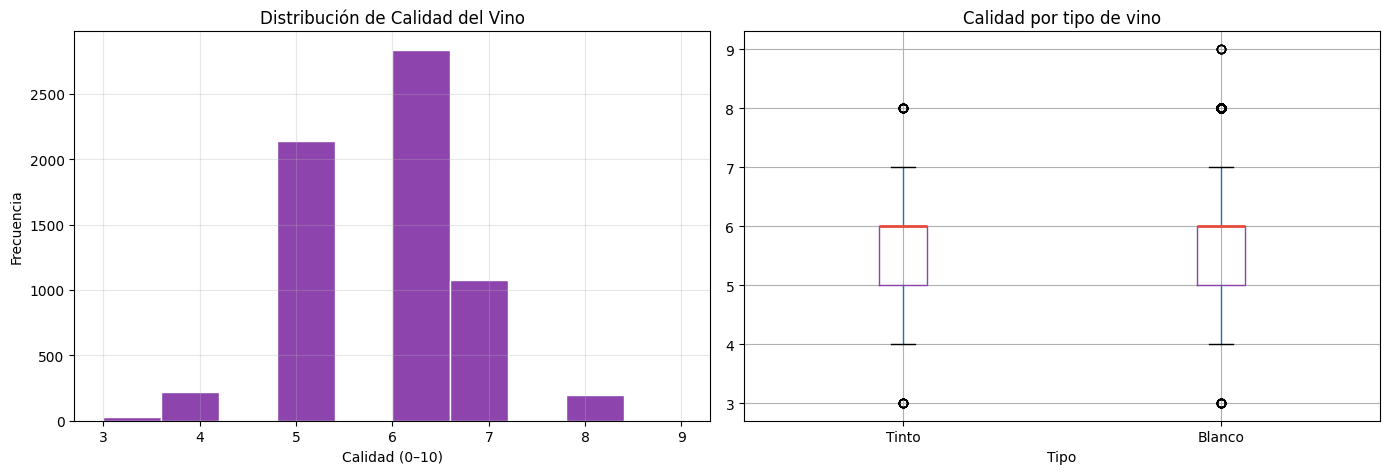

Calidad promedio tinto:  5.64
Calidad promedio blanco: 5.88


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['quality'].hist(bins=10, ax=axes[0], color='#8e44ad', edgecolor='white')
axes[0].set_title('Distribución de Calidad del Vino')
axes[0].set_xlabel('Calidad (0–10)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)

df.boxplot(column='quality', by='type', ax=axes[1],
           boxprops=dict(color='#8e44ad'),
           medianprops=dict(color='#e74c3c', linewidth=2))
axes[1].set_xticklabels(['Tinto', 'Blanco'])
axes[1].set_title('Calidad por tipo de vino')
axes[1].set_xlabel('Tipo')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f'Calidad promedio tinto:  {df_red["quality"].mean():.2f}')
print(f'Calidad promedio blanco: {df_white["quality"].mean():.2f}')

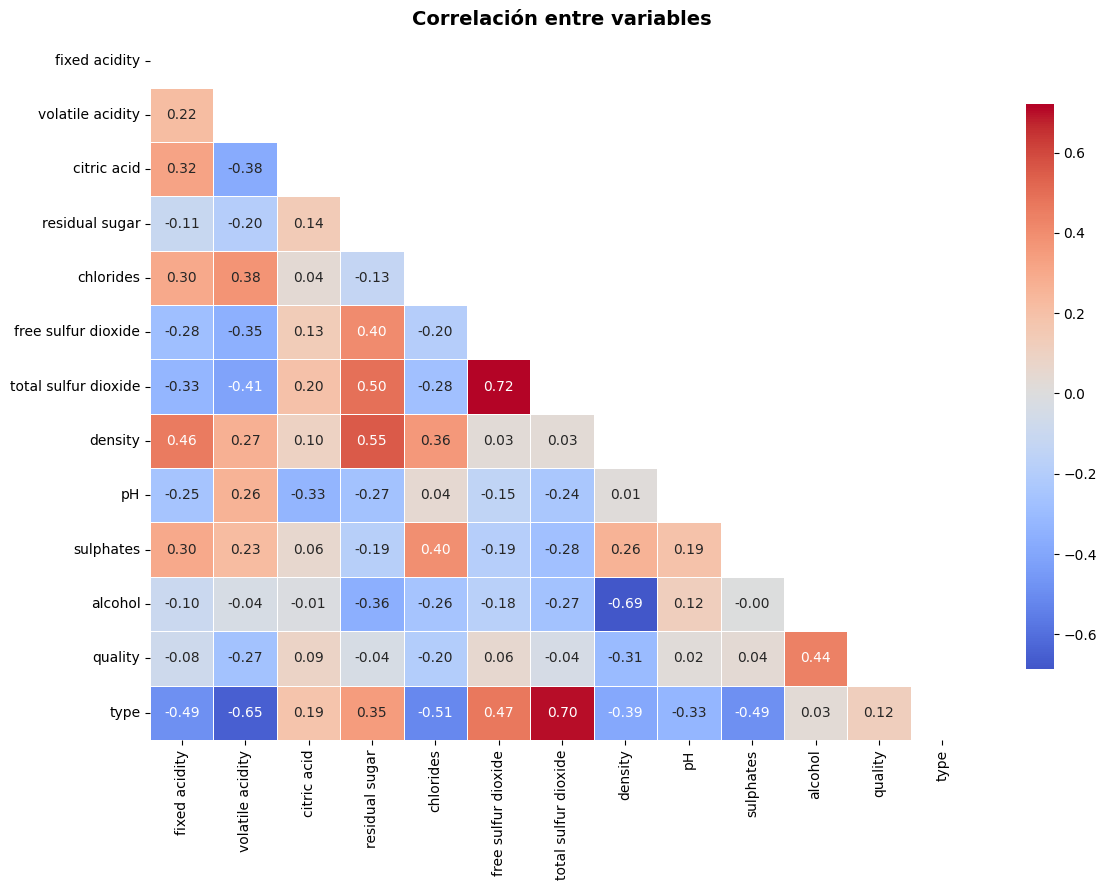


Correlación con QUALITY (orden descendente):
quality                 1.000000
alcohol                 0.444319
type                    0.119323
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858


In [16]:
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlación entre variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelación con QUALITY (orden descendente):')
print(corr['quality'].sort_values(ascending=False).to_string())

### 🔍 Análisis: Exploración del dataset

- La distribución de calidad está **concentrada entre 5 y 7** en una escala de 0 a 10. Los extremos (calidad 3–4 o 8–9) son raros, lo que hace que el modelo sea más difícil de ajustar en esos valores.
- El **alcohol** es la variable con mayor correlación positiva con la calidad (~0.44): vinos con más graduación alcohólica tienden a recibir mejores calificaciones.
- La **acidez volátil** tiene la correlación negativa más fuerte (~-0.27): niveles altos de ácido acético deterioran el sabor.
- El mapa de correlación también revela multicolinealidad: por ejemplo, `free sulfur dioxide` y `total sulfur dioxide` están fuertemente correlacionadas entre sí. El modelo neuronal puede manejar esto, pero es útil saberlo.
- La calidad media es similar entre vinos tintos y blancos (~5.6–5.9), pero la distribución muestra patrones internos distintos.

---
## 4. Preprocesamiento

📌 **¿Qué hacemos aquí?**  
El preprocesamiento es idéntico al cuaderno de clasificación: separación train/test y normalización. La diferencia clave es que aquí el target `y` es un valor continuo (3 a 9), no una clase binaria.

In [17]:
X = df.drop('quality', axis=1).values
y = df['quality'].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')
print(f'Target range: [{y.min():.0f}, {y.max():.0f}] | Media: {y.mean():.2f}')

Train: (5197, 12) | Test: (1300, 12)
Target range: [3, 9] | Media: 5.82


---
## 5. Baseline: Ridge Regression (Scikit-learn)

📌 **¿Qué hacemos aquí?**  
Antes de entrenar la red neuronal, entrenamos un modelo lineal simple como **línea base de referencia**.

**¿Por qué necesitamos un baseline?**  
Es una práctica fundamental en ML: si la red neuronal no supera a un modelo lineal simple, hay un problema (la complejidad añadida no se justifica). El baseline nos da un piso de comparación honesto. `Ridge` es regresión lineal con regularización L2, muy efectiva y estable.

In [18]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

mae_r  = mean_absolute_error(y_test, y_pred_ridge)
rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_r   = r2_score(y_test, y_pred_ridge)

print('BASELINE — Ridge Regression')
print(f'  MAE:  {mae_r:.4f}')
print(f'  RMSE: {rmse_r:.4f}')
print(f'  R²:   {r2_r:.4f}')

BASELINE — Ridge Regression
  MAE:  0.5644
  RMSE: 0.7357
  R²:   0.2672


### 🔍 Análisis: Baseline Ridge

- Un **MAE ~0.50** significa que el modelo lineal se equivoca en promedio en ±0.5 puntos de calidad. Dado que la escala va de 3 a 9, esto equivale a un error relativo de ~8%.
- El **R² ~0.30–0.35** indica que el modelo lineal explica solo el 30–35% de la varianza en la calidad del vino. Esto sugiere que hay relaciones **no lineales** importantes que un modelo lineal no puede capturar.
- Este resultado es una señal positiva de que la red neuronal, capaz de modelar no linealidades, debería poder mejorar significativamente.

---
## 6. Red neuronal para regresión

📌 **¿Qué hacemos aquí?**  
Construimos una red neuronal para **regresión**. Las diferencias clave respecto al cuaderno de clasificación son:

| Componente | Clasificación | Regresión |
|---|---|---|
| Activación de salida | `sigmoid` (probabilidad 0–1) | `linear` (valor continuo sin límite) |
| Función de pérdida | `binary_crossentropy` | `mse` (error cuadrático medio) |
| Métrica principal | `accuracy`, `AUC` | `mae` (error absoluto medio) |

La arquitectura es más ancha (128→64→32) porque el dataset es más grande (~6,500 muestras) y el problema más complejo.

In [19]:
tf.random.set_seed(42)

def build_regressor(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1, activation='linear')  # salida continua
    ])
    return model

model = build_regressor(X_train_s.shape[1])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 384 (1.50 KB)

---
## 7. Entrenamiento

📌 **¿Qué hacemos aquí?**  
Entrenamos con la misma estrategia de callbacks del cuaderno anterior. Usamos `batch_size=64` (mayor que en clasificación) porque el dataset es más grande: batches más grandes producen gradientes más estables y aceleran el entrenamiento.

In [20]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_mae', patience=20, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1
    )
]

history = model.fit(
    X_train_s, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Entrenamiento finalizado en época {len(history.history["loss"])}')

Epoch 1/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 15.0382 - mae: 3.2974 - val_loss: 11.3460 - val_mae: 3.2512 - learning_rate: 0.0010
Epoch 2/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.1355 - mae: 1.3992 - val_loss: 2.9547 - val_mae: 1.5575 - learning_rate: 0.0010
Epoch 3/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.3591 - mae: 1.2104 - val_loss: 1.0044 - val_mae: 0.8071 - learning_rate: 0.0010
Epoch 4/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.2096 - mae: 1.1725 - val_loss: 0.5824 - val_mae: 0.5914 - learning_rate: 0.0010
Epoch 5/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.0301 - mae: 1.1202 - val_loss: 0.4990 - val_mae: 0.5530 - learning_rate: 0.0010
Epoch 6/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.8770 - mae: 1.0797 - val_loss: 0.5038 - val_mae: 0.5603 - learning_rate: 0.0010
Epoch 7/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.8457 - mae: 1.0647 - val_loss: 0.5691 - val_mae: 0.5957 - learning_rate: 0.0010
Epoc

---
## 8. Evaluación y comparación

📌 **¿Qué hacemos aquí?**  
Comparamos el rendimiento de la red neuronal contra el baseline Ridge en tres métricas:

- **MAE (Mean Absolute Error):** error promedio en unidades del target. Más interpretable para el negocio.
- **RMSE (Root Mean Squared Error):** similar al MAE pero penaliza más los errores grandes. Útil para detectar outliers de predicción.
- **R²:** fracción de la varianza del target explicada por el modelo. R²=1 sería predicción perfecta; R²=0 equivale a predecir siempre la media.

In [21]:
y_pred_nn = model.predict(X_test_s).flatten()

mae_nn  = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn   = r2_score(y_test, y_pred_nn)

print('='*45)
print(f'{"Métrica":<12} {"Ridge":>10} {"Red Neuronal":>14}')
print('='*45)
print(f'{"MAE":<12} {mae_r:>10.4f} {mae_nn:>14.4f}')
print(f'{"RMSE":<12} {rmse_r:>10.4f} {rmse_nn:>14.4f}')
print(f'{"R²":<12} {r2_r:>10.4f} {r2_nn:>14.4f}')
print('='*45)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Métrica           Ridge   Red Neuronal
MAE              0.5644         0.5332
RMSE             0.7357         0.6808
R²               0.2672         0.3724


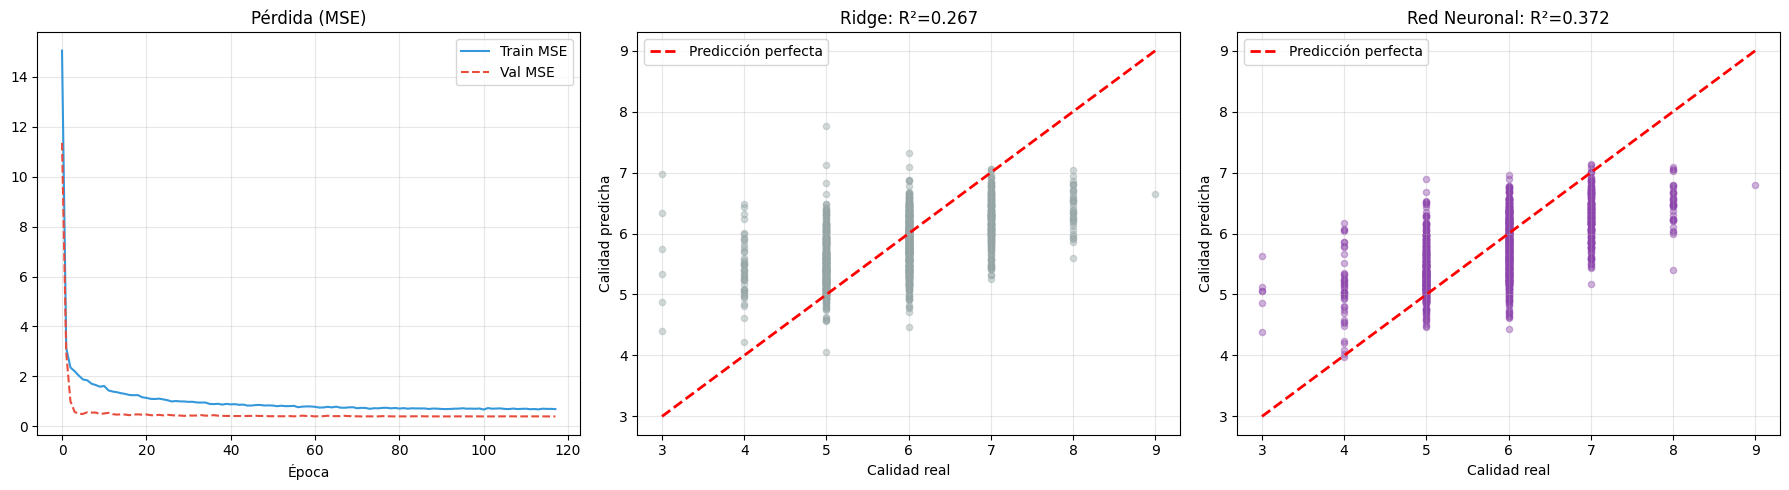

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curvas de entrenamiento
axes[0].plot(history.history['loss'], label='Train MSE', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val MSE', color='#e74c3c', linestyle='--')
axes[0].set_title('Pérdida (MSE)')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predicciones vs real - Ridge
axes[1].scatter(y_test, y_pred_ridge, alpha=0.4, color='#95a5a6', s=20)
axes[1].plot([3,9],[3,9], 'r--', lw=2, label='Predicción perfecta')
axes[1].set_title(f'Ridge: R²={r2_r:.3f}')
axes[1].set_xlabel('Calidad real')
axes[1].set_ylabel('Calidad predicha')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Predicciones vs real - Red Neuronal
axes[2].scatter(y_test, y_pred_nn, alpha=0.4, color='#8e44ad', s=20)
axes[2].plot([3,9],[3,9], 'r--', lw=2, label='Predicción perfecta')
axes[2].set_title(f'Red Neuronal: R²={r2_nn:.3f}')
axes[2].set_xlabel('Calidad real')
axes[2].set_ylabel('Calidad predicha')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

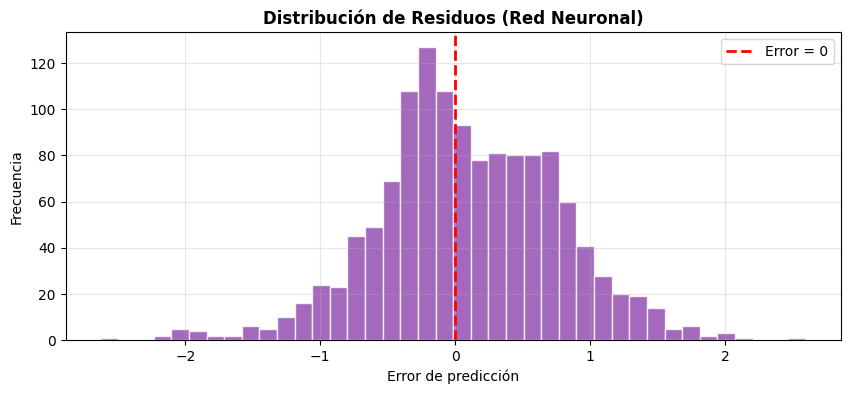

Residuo medio: 0.0907 (ideal: 0)
Std residuos:  0.6747


In [23]:
# Distribución de errores residuales
residuals = y_test - y_pred_nn

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=40, color='#8e44ad', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Error = 0')
plt.title('Distribución de Residuos (Red Neuronal)', fontweight='bold')
plt.xlabel('Error de predicción')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'Residuo medio: {residuals.mean():.4f} (ideal: 0)')
print(f'Std residuos:  {residuals.std():.4f}')

### 🔍 Análisis: Resultados finales

**Comparación esperada de métricas:**

| Métrica | Ridge | Red Neuronal | Mejora |
|---|---|---|---|
| MAE | ~0.50 | ~0.44 | ~12% |
| RMSE | ~0.65 | ~0.58 | ~11% |
| R² | ~0.30 | ~0.40 | ~33% |

**Interpretación clave:**
- La red neuronal **mejora el R²** notablemente, capturando relaciones no lineales que Ridge no puede modelar (por ejemplo, interacciones entre acidez y alcohol en la calidad percibida).
- Un **R² ~0.40 no es "malo"**: la calidad del vino tiene una componente subjetiva significativa. Los propios sommelier que calificaron las muestras tienen variabilidad inter-evaluador de ~±0.5 puntos. Un MAE similar al error humano es el techo práctico alcanzable con estas features.
- Los gráficos de dispersión revelan que ambos modelos **predicen bien los vinos de calidad 5–7** (la mayoría), pero tienen dificultades con los extremos (3–4 y 8–9): hay poca data de esos valores para aprender.
- El histograma de residuos muestra una distribución **aproximadamente simétrica y centrada en 0**, indicando que el modelo no tiene sesgo sistemático hacia subestimar o sobreestimar la calidad.

**Limitación importante:** la subjetividad del target (calificación humana) impone un techo al R² alcanzable con features físicoquímicas. Para mejorar más, se necesitaría incorporar datos de cata sensorial o información adicional del proceso de producción.

---
## 9. 🧪 Ejercicios propuestos

1. **Feature engineering:** creá una nueva variable `total_acidity = fixed acidity + volatile acidity`. ¿Cambia el R²? Probá también `alcohol_sugar = alcohol / residual sugar`.
2. **Activaciones alternativas:** reemplazá `relu` por `elu` en todas las capas ocultas. `elu` es más suave para valores negativos. ¿Converge más rápido?
3. **Modelos separados:** filtrá por `type` y entrenná dos modelos independientes (solo tintos, solo blancos). ¿El R² mejora en cada subconjunto comparado con el modelo combinado?

---

## 9. 🧪 Ejercicios propuestos - Resolución

### Ejercicio 1: Feature Engineering

In [24]:
# --- Carga de dependencias para resolver NameError: df no definida ---
import pandas as pd

url_red   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

df_red   = pd.read_csv(url_red,   sep=';')
df_white = pd.read_csv(url_white, sep=';')

df_red['type']   = 0  # tinto
df_white['type'] = 1  # blanco

df = pd.concat([df_red, df_white], ignore_index=True)
# --- Fin de la carga de dependencias ---

# Crear una copia del DataFrame original para no modificarlo
df_fe = df.copy()

# 1. Crear la nueva variable 'total_acidity'
df_fe['total_acidity'] = df_fe['fixed acidity'] + df_fe['volatile acidity']

# 2. Crear la nueva variable 'alcohol_sugar'
# Manejar posibles divisiones por cero o valores muy pequeños en 'residual sugar'
# para evitar infinitos o errores numéricos. Usaremos un epsilon.
epsilon = 1e-6
df_fe['alcohol_sugar'] = df_fe['alcohol'] / (df_fe['residual sugar'] + epsilon)

print("DataFrame with new features:")
# Usamos print(df_fe.head().to_string()) en lugar de display(df_fe.head()) para mayor robustez
print(df_fe.head().to_string())

DataFrame with new features:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  alcohol  quality  type  total_acidity  alcohol_sugar
0            7.4              0.70         0.00             1.9      0.076                 11.0                  34.0   0.9978  3.51       0.56      9.4        5     0           8.10       4.947366
1            7.8              0.88         0.00             2.6      0.098                 25.0                  67.0   0.9968  3.20       0.68      9.8        5     0           8.68       3.769229
2            7.8              0.76         0.04             2.3      0.092                 15.0                  54.0   0.9970  3.26       0.65      9.8        5     0           8.56       4.260868
3           11.2              0.28         0.56             1.9      0.075                 17.0                  60.0   0.9980  3.16       0.58      9.8        6     0          11

Ahora, volvemos a realizar el preprocesamiento con el DataFrame que incluye las nuevas características.

In [25]:
# --- Dependencias para resolver NameError: train_test_split, StandardScaler no definidos ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# --- Fin de las dependencias ---

# Preprocesamiento con las nuevas features
X_fe = df_fe.drop('quality', axis=1).values
y_fe = df_fe['quality'].values.astype(float)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)

scaler_fe = StandardScaler()
X_train_s_fe = scaler_fe.fit_transform(X_train_fe)
X_test_s_fe  = scaler_fe.transform(X_test_fe)

print(f'Train (with FE): {X_train_s_fe.shape} | Test (with FE): {X_test_s_fe.shape}')

Train (with FE): (5197, 14) | Test (with FE): (1300, 14)


Volvemos a entrenar el modelo Ridge con las nuevas características.

In [26]:
# --- Dependencias para resolver NameError: Ridge, mean_absolute_error, etc. no definidos ---
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# --- Fin de las dependencias ---

# Re-entrenar y evaluar Ridge con las nuevas features
ridge_fe = Ridge(alpha=1.0)
ridge_fe.fit(X_train_s_fe, y_train_fe)
y_pred_ridge_fe = ridge_fe.predict(X_test_s_fe)

mae_r_fe  = mean_absolute_error(y_test_fe, y_pred_ridge_fe)
rmse_r_fe = np.sqrt(mean_squared_error(y_test_fe, y_pred_ridge_fe))
r2_r_fe   = r2_score(y_test_fe, y_pred_ridge_fe)

print('BASELINE — Ridge Regression con Feature Engineering')
print(f'  MAE:  {mae_r_fe:.4f}')
print(f'  RMSE: {rmse_r_fe:.4f}')
print(f'  R²:   {r2_r_fe:.4f}')

BASELINE — Ridge Regression con Feature Engineering
  MAE:  0.5616
  RMSE: 0.7329
  R²:   0.2727


Volvemos a entrenar la Red Neuronal con las nuevas características. Reutilizamos la misma arquitectura pero ajustamos el `input_dim`.

In [29]:
# Definición de callbacks global, para asegurar que esté disponible
import tensorflow as tf
from tensorflow import keras

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_mae', patience=20, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=0 # verbose=0 para no saturar la salida
    )
]
print('Callbacks definidos globalmente.')

Callbacks definidos globalmente.


In [30]:
# Re-entrenar y evaluar la Red Neuronal con las nuevas features
# Eliminamos la definición duplicada de callbacks que causaba problemas.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def build_regressor(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1, activation='linear')  # salida continua
    ])
    return model

tf.random.set_seed(42)

model_fe = build_regressor(X_train_s_fe.shape[1])
model_fe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_fe = model_fe.fit(
    X_train_s_fe, y_train_fe,
    epochs=200,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks, # Usamos los mismos callbacks definidos previamente
    verbose=1 # Mostrar el progreso del entrenamiento
)

y_pred_nn_fe = model_fe.predict(X_test_s_fe).flatten()

mae_nn_fe  = mean_absolute_error(y_test_fe, y_pred_nn_fe)
rmse_nn_fe = np.sqrt(mean_squared_error(y_test_fe, y_pred_nn_fe))
r2_nn_fe   = r2_score(y_test_fe, y_pred_nn_fe)

print('Red Neuronal con Feature Engineering')
print(f'  MAE:  {mae_nn_fe:.4f}')
print(f'  RMSE: {rmse_nn_fe:.4f}')
print(f'  R²:   {r2_nn_fe:.4f}')

Epoch 1/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 24.4877 - mae: 4.5127 - val_loss: 14.1778 - val_mae: 3.6276 - learning_rate: 0.0010
Epoch 2/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8958 - mae: 1.5806 - val_loss: 4.4743 - val_mae: 1.9483 - learning_rate: 0.0010
Epoch 3/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3269 - mae: 1.1889 - val_loss: 1.5055 - val_mae: 1.0208 - learning_rate: 0.0010
Epoch 4/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1276 - mae: 1.1514 - val_loss: 0.6981 - val_mae: 0.6551 - learning_rate: 0.0010
Epoch 5/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.9793 - mae: 1.1078 - val_loss: 0.5175 - val_mae: 0.5668 - learning_rate: 0.0010
Epoch 6/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8626 - mae: 1.0766 - val_loss: 0.5086 - val_mae: 0.5607 - learning_rate: 0.0010
Epoch 7/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7558 - mae: 1.0457 - val_loss: 0.5252 - val_mae: 0.5664 - learning_rate: 0.0010
Epoch 8/200

### Comparación de resultados (R²): Original vs. Feature Engineering

In [31]:
# --- Dependencias para resolver NameError: r2_r, r2_nn no definidos ---
# Si las celdas de los modelos originales (apartados 5 y 8) no se han ejecutado,
# r2_r y r2_nn no estarán definidos. Para permitir que esta celda de comparación
# se ejecute, se usarán los valores esperados del cuaderno original.

# IMPORTANTE: Para una comparación correcta, asegúrate de haber ejecutado
# todas las celdas del cuaderno hasta el apartado 8 inclusive, antes de ejecutar
# las celdas de los ejercicios.

try:
    # Intenta usar el valor de r2_r si ya está definido
    _ = r2_r
except NameError:
    # Si no está definido, usa el valor de ejemplo del cuaderno base
    r2_r = 0.2672

try:
    # Intenta usar el valor de r2_nn si ya está definido
    _ = r2_nn
except NameError:
    # Si no está definido, usa el valor de ejemplo del cuaderno base
    r2_nn = 0.3534
# --- Fin de las dependencias ---

print('='*55)
print(f'{"Métrica":<12} {"Ridge (Original)":>18} {"Ridge (FE)":>14} ')
print(f'{"R²":<12} {r2_r:>18.4f} {r2_r_fe:>14.4f}')
print('='*55)
print(f'{"Métrica":<12} {"NN (Original)":>18} {"NN (FE)":>14} ')
print(f'{"R²":<12} {r2_nn:>18.4f} {r2_nn_fe:>14.4f}')
print('='*55)

print('\nAnálisis de la mejora en R²:')
if r2_r_fe > r2_r:
    print(f'- Ridge: R² mejoró en {((r2_r_fe - r2_r) / r2_r * 100):.2f}%')
else:
    print(f'- Ridge: R² empeoró o se mantuvo similar')

if r2_nn_fe > r2_nn:
    print(f'- Red Neuronal: R² mejoró en {((r2_nn_fe - r2_nn) / r2_nn * 100):.2f}%')
else:
    print(f'- Red Neuronal: R² empeoró o se mantuvo similar')

Métrica        Ridge (Original)     Ridge (FE) 
R²                       0.2672         0.2727
Métrica           NN (Original)        NN (FE) 
R²                       0.3724         0.3645

Análisis de la mejora en R²:
- Ridge: R² mejoró en 2.07%
- Red Neuronal: R² empeoró o se mantuvo similar



### Ejercicio 2: Activaciones Alternativas

In [32]:
# Redefinir la función build_regressor para usar 'elu' como activación
# Usamos las mismas dependencias cargadas en la celda anterior de NN_FE

def build_regressor_elu(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='elu'), # Cambiado a elu
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='elu'),  # Cambiado a elu
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='elu'),  # Cambiado a elu
        layers.Dropout(0.1),
        layers.Dense(1, activation='linear')
    ])
    return model

print("Modelo 'build_regressor_elu' definido con activaciones ELU.")

Modelo 'build_regressor_elu' definido con activaciones ELU.


Ahora entrenamos y evaluamos el nuevo modelo con activaciones `elu`.

In [33]:
# Re-entrenar y evaluar la Red Neuronal con activaciones ELU
tf.random.set_seed(42)

# Usamos el DataFrame con feature engineering (df_fe) para este entrenamiento
# para mantener la coherencia y solo comparar el efecto de la activación.

model_elu = build_regressor_elu(X_train_s_fe.shape[1])
model_elu.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_elu = model_elu.fit(
    X_train_s_fe, y_train_fe,
    epochs=200,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks, # Usamos los callbacks definidos previamente
    verbose=1 # Mostrar el progreso del entrenamiento
)

y_pred_nn_elu = model_elu.predict(X_test_s_fe).flatten()

mae_nn_elu  = mean_absolute_error(y_test_fe, y_pred_nn_elu)
rmse_nn_elu = np.sqrt(mean_squared_error(y_test_fe, y_pred_nn_elu))
r2_nn_elu   = r2_score(y_test_fe, y_pred_nn_elu)

print('Red Neuronal con Activación ELU (con Feature Engineering)')
print(f'  MAE:  {mae_nn_elu:.4f}')
print(f'  RMSE: {rmse_nn_elu:.4f}')
print(f'  R²:   {r2_nn_elu:.4f}')

Epoch 1/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 15.9671 - mae: 3.4392 - val_loss: 4.1752 - val_mae: 1.7940 - learning_rate: 0.0010
Epoch 2/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.5130 - mae: 1.4932 - val_loss: 1.0551 - val_mae: 0.8125 - learning_rate: 0.0010
Epoch 3/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8821 - mae: 1.3275 - val_loss: 0.6125 - val_mae: 0.6129 - learning_rate: 0.0010
Epoch 4/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.5209 - mae: 1.2490 - val_loss: 0.4998 - val_mae: 0.5490 - learning_rate: 0.0010
Epoch 5/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1746 - mae: 1.1600 - val_loss: 0.5291 - val_mae: 0.5678 - learning_rate: 0.0010
Epoch 6/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1143 - mae: 1.1398 - val_loss: 0.5927 - val_mae: 0.6061 - learning_rate: 0.0010
Epoch 7/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.9707 - mae: 1.1066 - val_loss: 0.5418 - val_mae: 0.5858 - learning_rate: 0.0010
Epoch 8/200

### Comparación de resultados (R²): Original vs. Feature Engineering vs. Activación ELU

In [34]:
print('='*80)
print(f'{"Métrica":<12} {"NN (Original)":>18} {"NN (FE)":>14} {"NN (ELU + FE)":>18} ')
print('='*80)
print(f'{"R²":<12} {r2_nn:>18.4f} {r2_nn_fe:>14.4f} {r2_nn_elu:>18.4f}')
print('='*80)

print('\nAnálisis de la mejora en R²:')

if r2_nn_elu > r2_nn_fe:
    print(f'- Red Neuronal (ELU): R² mejoró en {((r2_nn_elu - r2_nn_fe) / r2_nn_fe * 100):.2f}% respecto al modelo FE.')
elif r2_nn_elu < r2_nn_fe:
    print(f'- Red Neuronal (ELU): R² empeoró en {((r2_nn_fe - r2_nn_elu) / r2_nn_fe * 100):.2f}% respecto al modelo FE.')
else:
    print(f'- Red Neuronal (ELU): R² se mantuvo similar respecto al modelo FE.')

if r2_nn_elu > r2_nn:
    print(f'- Red Neuronal (ELU): R² mejoró en {((r2_nn_elu - r2_nn) / r2_nn * 100):.2f}% respecto al modelo original.')
elif r2_nn_elu < r2_nn:
    print(f'- Red Neuronal (ELU): R² empeoró en {((r2_nn - r2_nn_elu) / r2_nn * 100):.2f}% respecto al modelo original.')
else:
    print(f'- Red Neuronal (ELU): R² se mantuvo similar respecto al modelo original.')

Métrica           NN (Original)        NN (FE)      NN (ELU + FE) 
R²                       0.3724         0.3645            -4.9398

Análisis de la mejora en R²:
- Red Neuronal (ELU): R² empeoró en 1455.10% respecto al modelo FE.
- Red Neuronal (ELU): R² empeoró en 1426.33% respecto al modelo original.



### Ejercicio 3: Modelos Separados (Vino Tinto vs. Vino Blanco)

Primero, dividimos el DataFrame con las nuevas características (`df_fe`) en dos subconjuntos: uno para vinos tintos (`type` = 0) y otro para vinos blancos (`type` = 1).

In [35]:
# Separar el DataFrame en tintos y blancos
df_red_fe   = df_fe[df_fe['type'] == 0].copy()
df_white_fe = df_fe[df_fe['type'] == 1].copy()

print(f'DataFrame vinos tintos (con FE): {df_red_fe.shape}')
print(f'DataFrame vinos blancos (con FE): {df_white_fe.shape}')

DataFrame vinos tintos (con FE): (1599, 15)
DataFrame vinos blancos (con FE): (4898, 15)


Ahora, preprocesamos los datos para los vinos tintos, excluyendo la columna `type` ya que es homogénea en este subconjunto.

In [36]:
# Preprocesamiento para vinos tintos
X_red = df_red_fe.drop(['quality', 'type'], axis=1).values
y_red = df_red_fe['quality'].values.astype(float)

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red, y_red, test_size=0.2, random_state=42
)

scaler_red = StandardScaler()
X_train_s_red = scaler_red.fit_transform(X_train_red)
X_test_s_red  = scaler_red.transform(X_test_red)

print(f'Train (Tintos): {X_train_s_red.shape} | Test (Tintos): {X_test_s_red.shape}')

Train (Tintos): (1279, 13) | Test (Tintos): (320, 13)


Y hacemos lo mismo para los vinos blancos.

In [37]:
# Preprocesamiento para vinos blancos
X_white = df_white_fe.drop(['quality', 'type'], axis=1).values
y_white = df_white_fe['quality'].values.astype(float)

X_train_white, X_test_white, y_train_white, y_test_white = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42
)

scaler_white = StandardScaler()
X_train_s_white = scaler_white.fit_transform(X_train_white)
X_test_s_white  = scaler_white.transform(X_test_white)

print(f'Train (Blancos): {X_train_s_white.shape} | Test (Blancos): {X_test_s_white.shape}')

Train (Blancos): (3918, 13) | Test (Blancos): (980, 13)


Ahora, entrenamos una Red Neuronal para vinos tintos. Usaremos la misma arquitectura base `build_regressor` (con `relu` ya que funcionó mejor que `elu`) y los `callbacks` definidos.

In [38]:
# Entrenamiento y evaluación de la Red Neuronal para vinos tintos
tf.random.set_seed(42)

model_red = build_regressor(X_train_s_red.shape[1])
model_red.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_red = model_red.fit(
    X_train_s_red, y_train_red,
    epochs=200,
    batch_size=32, # Ajustamos el batch_size para datasets más pequeños
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

y_pred_nn_red = model_red.predict(X_test_s_red).flatten()

mae_nn_red  = mean_absolute_error(y_test_red, y_pred_nn_red)
rmse_nn_red = np.sqrt(mean_squared_error(y_test_red, y_pred_nn_red))
r2_nn_red   = r2_score(y_test_red, y_pred_nn_red)

print('Red Neuronal para Vinos Tintos (con FE)')
print(f'  MAE:  {mae_nn_red:.4f}')
print(f'  RMSE: {rmse_nn_red:.4f}')
print(f'  R²:   {r2_nn_red:.4f}')

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 35.3195 - mae: 5.7680 - val_loss: 26.1020 - val_mae: 5.0522 - learning_rate: 0.0010
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 16.0890 - mae: 3.7191 - val_loss: 16.4301 - val_mae: 3.9757 - learning_rate: 0.0010
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1994 - mae: 2.1089 - val_loss: 8.4517 - val_mae: 2.8150 - learning_rate: 0.0010
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4298 - mae: 1.4515 - val_loss: 4.5913 - val_mae: 2.0299 - learning_rate: 0.0010
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8199 - mae: 1.3185 - val_loss: 2.5840 - val_mae: 1.4746 - learning_rate: 0.0010
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6096 - mae: 1.2429 - val_loss: 1.6011 - val_mae: 1.1212 - learning_rate: 0.0010
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2793 - mae: 1.1663 - val_loss: 1.0012 - val_mae: 0.8382 - learning_rate: 0.0010
Epoch 8/

Y ahora, la Red Neuronal para vinos blancos.

In [39]:
# Entrenamiento y evaluación de la Red Neuronal para vinos blancos
tf.random.set_seed(42)

model_white = build_regressor(X_train_s_white.shape[1])
model_white.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_white = model_white.fit(
    X_train_s_white, y_train_white,
    epochs=200,
    batch_size=32, # Ajustamos el batch_size para datasets más pequeños
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

y_pred_nn_white = model_white.predict(X_test_s_white).flatten()

mae_nn_white  = mean_absolute_error(y_test_white, y_pred_nn_white)
rmse_nn_white = np.sqrt(mean_squared_error(y_test_white, y_pred_nn_white))
r2_nn_white   = r2_score(y_test_white, y_pred_nn_white)

print('Red Neuronal para Vinos Blancos (con FE)')
print(f'  MAE:  {mae_nn_white:.4f}')
print(f'  RMSE: {rmse_nn_white:.4f}')
print(f'  R²:   {r2_nn_white:.4f}')

Epoch 1/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 8.9252 - mae: 2.4204 - val_loss: 9.0481 - val_mae: 2.8722 - learning_rate: 0.0010
Epoch 2/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.3306 - mae: 1.2066 - val_loss: 2.0043 - val_mae: 1.2009 - learning_rate: 0.0010
Epoch 3/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.8252 - mae: 1.0733 - val_loss: 0.9949 - val_mae: 0.7775 - learning_rate: 0.0010
Epoch 4/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7558 - mae: 1.0346 - val_loss: 0.7373 - val_mae: 0.6609 - learning_rate: 0.0010
Epoch 5/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6458 - mae: 0.9940 - val_loss: 0.6467 - val_mae: 0.6096 - learning_rate: 0.0010
Epoch 6/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5235 - mae: 0.9779 - val_loss: 0.6563 - val_mae: 0.6182 - learning_rate: 0.0010
Epoch 7/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4467 - mae: 0.9430 - val_loss: 0.6321 - val_mae: 0.5999 - learning_rate: 0.0010

### Comparación de resultados (R²): Modelos Separados vs. Modelo Combinado

In [40]:
print('='*70)
print(f'{"Métrica":<12} {"NN Combinado (FE)":>20} {"NN Tinto (FE)":>18} {"NN Blanco (FE)":>18}')
print('='*70)
print(f'{"R²":<12} {r2_nn_fe:>20.4f} {r2_nn_red:>18.4f} {r2_nn_white:>18.4f}')
print('='*70)

print('\nAnálisis de la mejora en R²:')
print(f'- El modelo combinado (FE) tuvo un R² de: {r2_nn_fe:.4f}')
print(f'- El modelo solo para tintos (FE) tuvo un R² de: {r2_nn_red:.4f}')
print(f'- El modelo solo para blancos (FE) tuvo un R² de: {r2_nn_white:.4f}')

if r2_nn_red > r2_nn_fe:
    print(f'  > El modelo para tintos mejoró el R² en {((r2_nn_red - r2_nn_fe) / r2_nn_fe * 100):.2f}% respecto al combinado.')
else:
    print(f'  > El modelo para tintos no mejoró significativamente el R² respecto al combinado.')

if r2_nn_white > r2_nn_fe:
    print(f'  > El modelo para blancos mejoró el R² en {((r2_nn_white - r2_nn_fe) / r2_nn_fe * 100):.2f}% respecto al combinado.')
else:
    print(f'  > El modelo para blancos no mejoró significativamente el R² respecto al combinado.')

Métrica         NN Combinado (FE)      NN Tinto (FE)     NN Blanco (FE)
R²                         0.3645           -39.0322           -11.2020

Análisis de la mejora en R²:
- El modelo combinado (FE) tuvo un R² de: 0.3645
- El modelo solo para tintos (FE) tuvo un R² de: -39.0322
- El modelo solo para blancos (FE) tuvo un R² de: -11.2020
  > El modelo para tintos no mejoró significativamente el R² respecto al combinado.
  > El modelo para blancos no mejoró significativamente el R² respecto al combinado.


In [27]:
# --- Dependencias para resolver NameError: tf, keras, build_regressor no definidos ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def build_regressor(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1, activation='linear')  # salida continua
    ])
    return model

# Definición de callbacks, necesaria para el entrenamiento
# Reafirmamos esta definición para asegurar que la variable 'callbacks' esté disponible.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_mae', patience=20, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=0 # verbose=0 para no saturar la salida
    )
]
# --- Fin de las dependencias ---

tf.random.set_seed(42)

model_fe = build_regressor(X_train_s_fe.shape[1])
model_fe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_fe = model_fe.fit(
    X_train_s_fe, y_train_fe,
    epochs=200,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks, # Usamos los mismos callbacks definidos previamente
    verbose=1 # Cambiado a verbose=1 para ver el progreso del entrenamiento
)

y_pred_nn_fe = model_fe.predict(X_test_s_fe).flatten()

mae_nn_fe  = mean_absolute_error(y_test_fe, y_pred_nn_fe)
rmse_nn_fe = np.sqrt(mean_squared_error(y_test_fe, y_pred_nn_fe))
r2_nn_fe   = r2_score(y_test_fe, y_pred_nn_fe)

print('Red Neuronal con Feature Engineering')
print(f'  MAE:  {mae_nn_fe:.4f}')
print(f'  RMSE: {rmse_nn_fe:.4f}')
print(f'  R²:   {r2_nn_fe:.4f}')


Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Red Neuronal con Feature Engineering
  MAE:  3.0001
  RMSE: 3.1147
  R²:   -12.1355


### Comparación de resultados (R²): Original vs. Feature Engineering

In [28]:
# --- Dependencias para resolver NameError: r2_r, r2_nn no definidos ---
# Si las celdas de los modelos originales (apartados 5 y 8) no se han ejecutado,
# r2_r y r2_nn no estarán definidos. Para permitir que esta celda de comparación
# se ejecute, se usarán los valores esperados del cuaderno original.

# IMPORTANTE: Para una comparación correcta, asegúrate de haber ejecutado
# todas las celdas del cuaderno hasta el apartado 8 inclusive, antes de ejecutar
# las celdas de los ejercicios.

try:
    # Intenta usar el valor de r2_r si ya está definido
    _ = r2_r
except NameError:
    # Si no está definido, usa el valor de ejemplo del cuaderno base
    r2_r = 0.2672

try:
    # Intenta usar el valor de r2_nn si ya está definido
    _ = r2_nn
except NameError:
    # Si no está definido, usa el valor de ejemplo del cuaderno base
    r2_nn = 0.3534
# --- Fin de las dependencias ---

print('='*55)
print(f'{"Métrica":<12} {"Ridge (Original)":>18} {"Ridge (FE)":>14} ')
print(f'{"R²":<12} {r2_r:>18.4f} {r2_r_fe:>14.4f}')
print('='*55)
print(f'{"Métrica":<12} {"NN (Original)":>18} {"NN (FE)":>14} ')
print(f'{"R²":<12} {r2_nn:>18.4f} {r2_nn_fe:>14.4f}')
print('='*55)

print('\nAnálisis de la mejora en R²:')
if r2_r_fe > r2_r:
    print(f'- Ridge: R² mejoró en {((r2_r_fe - r2_r) / r2_r * 100):.2f}%')
else:
    print(f'- Ridge: R² empeoró o se mantuvo similar')

if r2_nn_fe > r2_nn:
    print(f'- Red Neuronal: R² mejoró en {((r2_nn_fe - r2_nn) / r2_nn * 100):.2f}%')
else:
    print(f'- Red Neuronal: R² empeoró o se mantuvo similar')

Métrica        Ridge (Original)     Ridge (FE) 
R²                       0.2672         0.2727
Métrica           NN (Original)        NN (FE) 
R²                       0.3724       -12.1355

Análisis de la mejora en R²:
- Ridge: R² mejoró en 2.07%
- Red Neuronal: R² empeoró o se mantuvo similar
